# E-Commerce Data Storytelling: Từ tăng trưởng doanh thu đến rủi ro hoàn trả

---

Notebook này kể lại câu chuyện kinh doanh qua **4 chương phân tích**, mỗi chương trả lời một câu hỏi chiến lược:

| Chương | Câu hỏi chiến lược | Phương pháp chính |
|:------:|:------|:------|
| **0** | Ai đang mua, và ai là "Core Customer"? | RFM Segmentation, Demographic breakdown |
| **1** | Kênh nào giữ chân khách tốt nhất? | Recency-based Churn Risk, Confidence Intervals |
| **2** | Khuyến mãi có thực sự tạo thêm giá trị? | Matched-pair Analysis (loại Selection Bias) |
| **3** | Rủi ro chất lượng và Churn nằm ở đâu? | Return impact analysis, Category profiling |

> **Lưu ý về LTV (Life-Time Value):** Trong giới hạn của dữ liệu lịch sử, chưa có mô hình dự phóng (predictive model như BG/NBD hay Gamma-Gamma). Các chỉ số giá trị vòng đời ở đây được tính bằng **Historical ARPU (Average Revenue Per User)** — tức tổng doanh thu chia cho số khách hàng. Đây là proxy hợp lý nhưng không phải "true LTV".

In [1]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Suppress toan bo FutureWarning ve palette/hue cua seaborn 0.14
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

DATA_DIR = Path("../data/raw")

customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

order_items["gross_revenue"] = order_items["quantity"] * order_items["unit_price"]
order_items["net_revenue"] = order_items["gross_revenue"] - order_items["discount_amount"].fillna(0.0)
order_items["promo_used_line"] = order_items[["promo_id", "promo_id_2"]].notna().any(axis=1)

# Toi uu RAM: chi lay cac cot can thiet truoc khi merge
order_value = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        promo_used=("promo_used_line", "max"),
    )
)

# Khau tru hoan tien (refund_amount) khoi net_revenue de ra doanh thu thuc te
returns_summary = returns.groupby("order_id", as_index=False)["refund_amount"].sum()
order_value = order_value.merge(returns_summary, on="order_id", how="left")
order_value["refund_amount"] = order_value["refund_amount"].fillna(0.0)
order_value["final_revenue"] = order_value["net_revenue"] - order_value["refund_amount"]

orders_enriched = orders.merge(order_value, on="order_id", how="left")
cols_to_merge = ["customer_id", "acquisition_channel", "age_group", "city"]
orders_enriched = orders_enriched.merge(
    customers[cols_to_merge],
    on="customer_id",
    how="left"
)

# --- TINH TOAN RFM & RECENCY ---
max_date = orders["order_date"].max()

rfm = (
    orders_enriched.groupby("customer_id", as_index=False)
    .agg(
        last_order_date=("order_date", "max"),
        Frequency=("order_id", "nunique"),
        Historical_ARPU=("final_revenue", "sum")
    )
)
rfm["Recency"] = (max_date - rfm["last_order_date"]).dt.days
rfm["Historical_ARPU_per_order"] = rfm["Historical_ARPU"] / rfm["Frequency"]

# Dinh nghia Churn Risk: Recency > 365 days
rfm["Churn_Risk"] = rfm["Recency"] > 365

# RFM Scoring (1-4, 4 la tot nhat; Recency 4 = gan day nhat)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1], duplicates='drop')
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Historical_ARPU"], q=4, labels=[1, 2, 3, 4], duplicates='drop')

def assign_segment(row):
    if row["R_Score"] == 4 and row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Champion"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal"
    elif row["Churn_Risk"]:
        return "At Risk / Churned"
    else:
        return "Standard"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)
customers_rfm = customers.merge(rfm, on="customer_id", how="left")

---
## Chuong 0. Demographic khach hang & Core Segments (RFM)

**Muc dich:** Truoc khi di vao cac cau hoi chien luoc, chung ta can hieu *ai dang mua* va *ai la "Core Customers"*.

- **RFM Segmentation** phan loai khach hang thanh 4 nhom: Champion, Loyal, Standard, At Risk/Churned.
- Bang duoi dung `style.format` ket hop `background_gradient` de lam noi bat cac chi so hieu suat thay vi dung `.round()` lam mat do chinh xac.

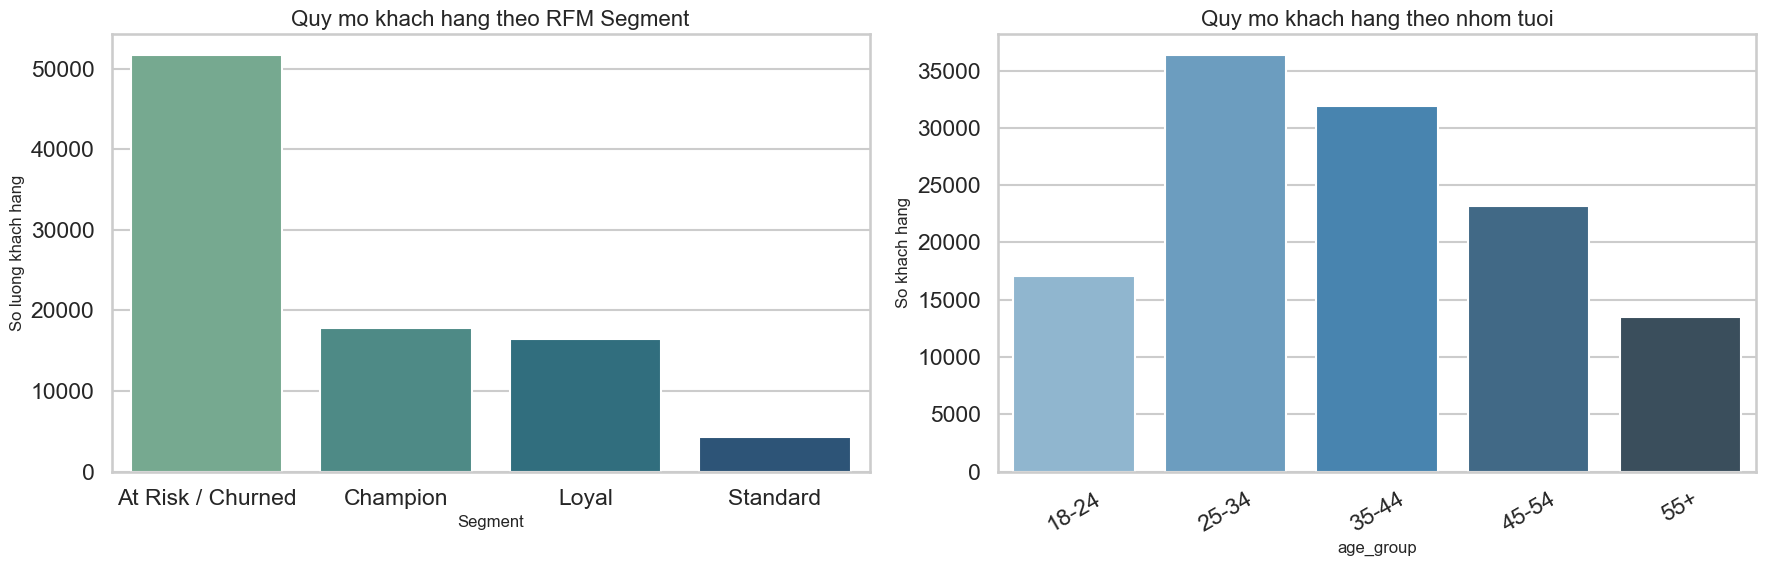

,Segment,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Historical_ARPU
1,Champion,"17,817",153.7 days,16.96 orders,"$7,285,182,620","$408,889"
2,Loyal,"16,495",586.3 days,11.24 orders,"$4,282,578,359","$259,629"
0,At Risk / Churned,"51,666","1,935.0 days",2.90 orders,"$3,357,224,398","$64,979"
3,Standard,"4,268",192.9 days,2.21 orders,"$245,285,382","$57,471"


In [2]:
# Bieu do Segment & Age
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

segment_counts = customers_rfm["Segment"].value_counts()
sns.barplot(
    x=segment_counts.index, y=segment_counts.values,
    hue=segment_counts.index, palette="crest", legend=False, ax=axes[0]
)
axes[0].set_title("Quy mo khach hang theo RFM Segment", fontsize=16)
axes[0].set_ylabel("So luong khach hang")

age_counts = customers_rfm["age_group"].dropna().value_counts().sort_index()
sns.barplot(
    x=age_counts.index, y=age_counts.values,
    hue=age_counts.index, palette="Blues_d", legend=False, ax=axes[1]
)
axes[1].set_title("Quy mo khach hang theo nhom tuoi", fontsize=16)
axes[1].set_ylabel("So khach hang")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Bang Summary theo Segment (style.format thay vi round)
segment_summary = (
    customers_rfm.groupby("Segment", as_index=False)
    .agg(
        Customers=("customer_id", "nunique"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Total_Revenue=("Historical_ARPU", "sum"),
        Avg_Historical_ARPU=("Historical_ARPU", "mean")
    )
).sort_values("Total_Revenue", ascending=False)

display(segment_summary.style.format({
    "Customers": "{:,.0f}",
    "Avg_Recency": "{:,.1f} days",
    "Avg_Frequency": "{:,.2f} orders",
    "Total_Revenue": "${:,.0f}",
    "Avg_Historical_ARPU": "${:,.0f}"
}).background_gradient(cmap="YlGnBu", subset=["Total_Revenue", "Avg_Historical_ARPU"]))

### Bang tong hop theo nhom tuoi

So sanh AOV, tan suat mua, va Historical ARPU giua cac nhom tuoi de xac dinh nhom nao dang tao gia tri cao nhat.

In [3]:
age_value = (
    orders_enriched.dropna(subset=["age_group"])
    .groupby("age_group", as_index=False)
    .agg(
        Customers=("customer_id", "nunique"),
        Orders=("order_id", "nunique"),
        Total_Revenue=("net_revenue", "sum"),
        Avg_Order_Value=("net_revenue", "mean")
    )
)
age_value["Orders_per_Customer"] = age_value["Orders"] / age_value["Customers"]
age_value["Historical_ARPU"] = age_value["Total_Revenue"] / age_value["Customers"]

age_summary = age_value.sort_values("Total_Revenue", ascending=False)

display(age_summary.style.format({
    "Customers": "{:,.0f}",
    "Orders": "{:,.0f}",
    "Total_Revenue": "${:,.0f}",
    "Avg_Order_Value": "${:,.0f}",
    "Orders_per_Customer": "{:,.2f}",
    "Historical_ARPU": "${:,.0f}"
}).background_gradient(cmap="YlGnBu", subset=["Total_Revenue", "Historical_ARPU"]))

,age_group,Customers,Orders,Total_Revenue,Avg_Order_Value,Orders_per_Customer,Historical_ARPU
1,25-34,"26,802","190,622","$4,630,010,667","$24,289",7.11,"$172,749"
2,35-44,"23,642","170,368","$4,126,281,874","$24,220",7.21,"$174,532"
3,45-54,"17,193","124,138","$3,019,379,835","$24,323",7.22,"$175,617"
0,18-24,"12,599","89,057","$2,152,381,726","$24,169",7.07,"$170,838"
4,55+,"10,010","72,760","$1,752,815,164","$24,090",7.27,"$175,106"


### Thanh pho nao chiu chi hon?

Ghep so khach hang va doanh thu de nhin ro thanh pho co quy mo lon hay thuc su "chiu chi" (Historical ARPU/khach cao).

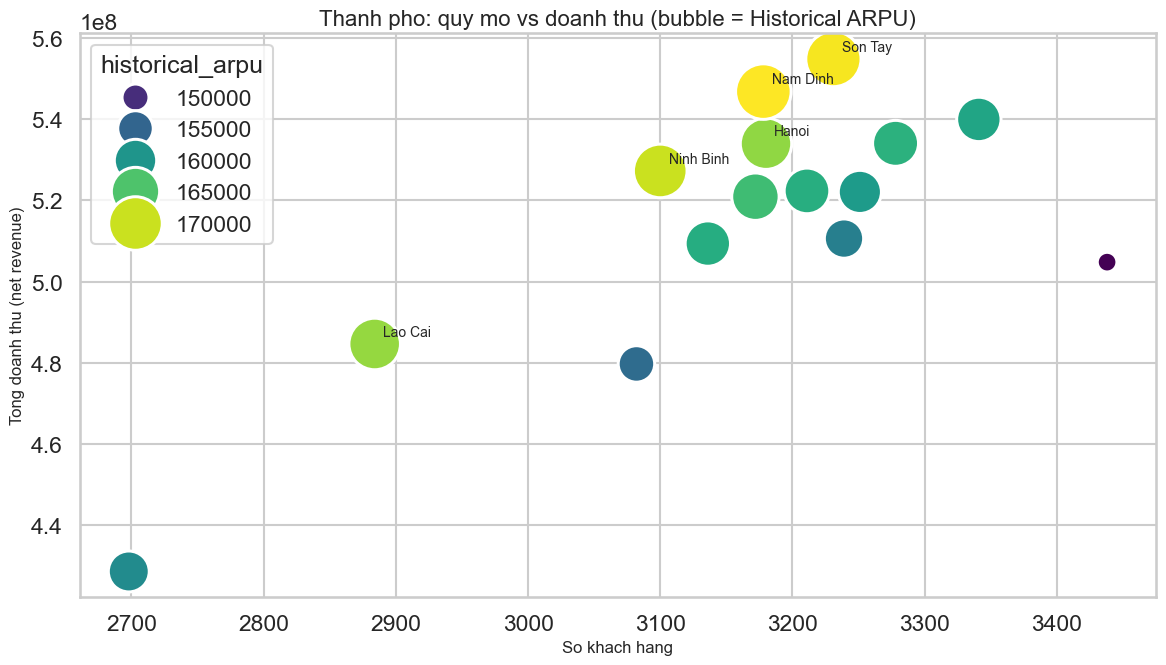

In [4]:
city_value = (
    orders_enriched.dropna(subset=["city"])
    .groupby("city", as_index=False)
    .agg(customers=("customer_id", "nunique"), total_revenue=("net_revenue", "sum"))
)
city_value["historical_arpu"] = city_value["total_revenue"] / city_value["customers"]

city_plot = city_value.sort_values("customers", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=city_plot,
    x="customers",
    y="total_revenue",
    size="historical_arpu",
    sizes=(200, 1600),
    hue="historical_arpu",
    palette="viridis",
    ax=ax,
    legend="brief",
)
ax.set_title("Thanh pho: quy mo vs doanh thu (bubble = Historical ARPU)", fontsize=16)
ax.set_xlabel("So khach hang")
ax.set_ylabel("Tong doanh thu (net revenue)")

for _, row in city_plot.sort_values("historical_arpu", ascending=False).head(5).iterrows():
    ax.annotate(
        row["city"],
        (row["customers"], row["total_revenue"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

---
**Nhan dinh tu Chuong 0:** Chung ta da biet *ai dang mua* va phan loai duoc nhom Core Customers bang RFM. Cau hoi tiep theo la: **kenh nao giu chan khach tot nhat, va kenh nao dang co nguy co mat khach?**

## Chuong 1. Phan bo rui ro Churn & Hieu suat Kenh thu hut (Acquisition)

**Muc dich:** Xem xet ty le khach hang co rui ro roi bo (Churn Risk = Recency > 365 days) o tung kenh Acquisition. Kenh nao mang lai ARPU tot *va* giu chan khach tot?

- Bieu do ARPU su dung **95% Confidence Interval** (`errorbar='ci'`) de loai tru nhieu du lieu khi so sanh gia tri giua cac kenh.
- Bieu do Churn Rate duoc tach rieng de tranh bi de label.

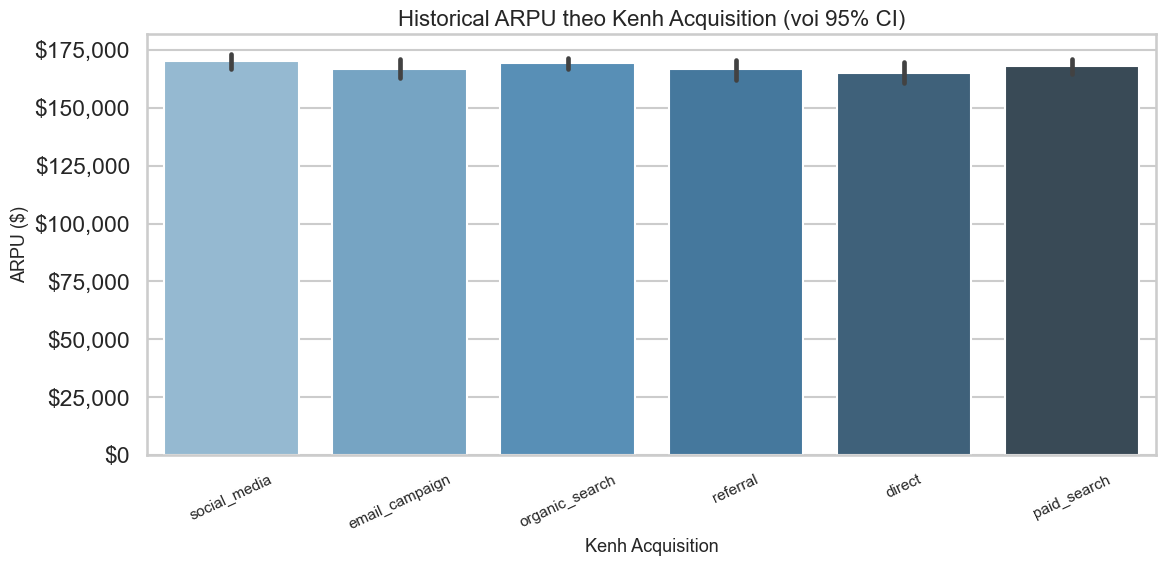

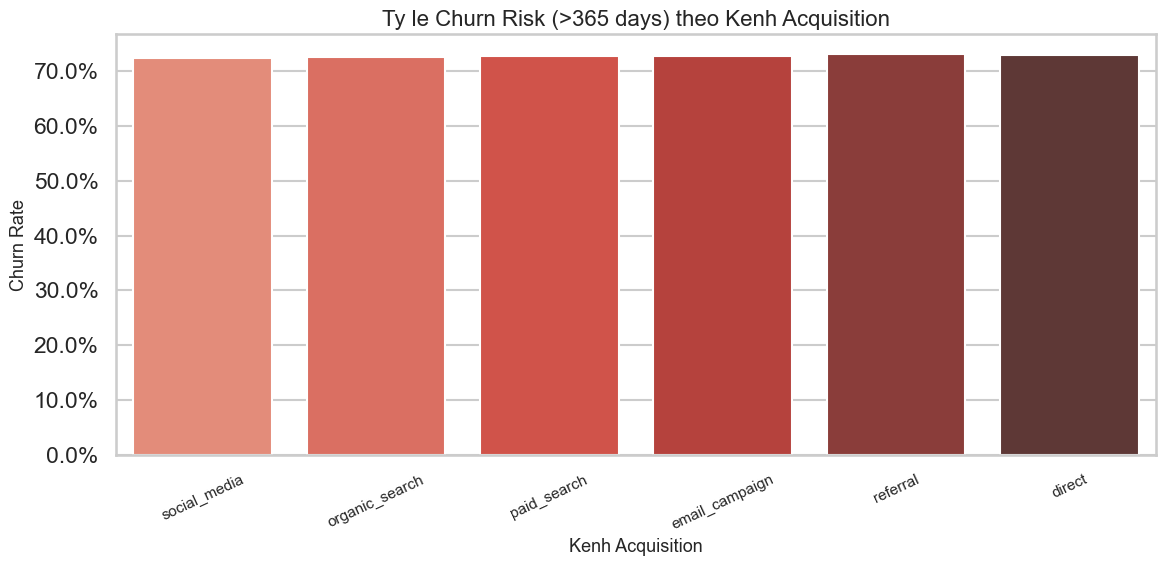

,acquisition_channel,Avg_ARPU,Churn_Rate
5,social_media,"$169,926.5",72.3%
2,organic_search,"$169,051.7",72.5%
3,paid_search,"$167,772.6",72.6%
1,email_campaign,"$166,648.7",72.6%
4,referral,"$166,468.2",73.0%
0,direct,"$165,085.7",72.8%


In [5]:
channel_metrics = (
    customers_rfm.groupby("acquisition_channel", as_index=False)
    .agg(
        Avg_ARPU=("Historical_ARPU", "mean"),
        Churn_Rate=("Churn_Risk", "mean")
    )
).sort_values("Avg_ARPU", ascending=False)

# --- BIEU DO 1: Historical ARPU theo Kenh (rieng biet, khong bi de label) ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=customers_rfm,
    x="acquisition_channel",
    y="Historical_ARPU",
    hue="acquisition_channel",
    palette="Blues_d",
    legend=False,
    ax=ax,
    errorbar=("ci", 95)
)
ax.set_title("Historical ARPU theo Kenh Acquisition (voi 95% CI)", fontsize=16)
ax.set_xlabel("Kenh Acquisition", fontsize=13)
ax.set_ylabel("ARPU ($)", fontsize=13)
ax.tick_params(axis="x", rotation=25, labelsize=11)
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:,.0f}")
plt.tight_layout()
plt.show()

# --- BIEU DO 2: Churn Rate theo Kenh (rieng biet) ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=channel_metrics,
    x="acquisition_channel",
    y="Churn_Rate",
    hue="acquisition_channel",
    palette="Reds_d",
    legend=False,
    ax=ax,
)
ax.set_title("Ty le Churn Risk (>365 days) theo Kenh Acquisition", fontsize=16)
ax.set_xlabel("Kenh Acquisition", fontsize=13)
ax.set_ylabel("Churn Rate", fontsize=13)
ax.tick_params(axis="x", rotation=25, labelsize=11)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
plt.tight_layout()
plt.show()

# Bang so sanh
display(channel_metrics.style.format({
    "Avg_ARPU": "${:,.1f}",
    "Churn_Rate": "{:.1%}"
}).background_gradient(cmap="Blues", subset=["Avg_ARPU"]).background_gradient(cmap="Reds", subset=["Churn_Rate"]))

---
**Nhan dinh tu Chuong 1:** Cac kenh Acquisition co ARPU va Churn Rate tuong doi dong deu, nhung su khac biet nho co y nghia kinh doanh khi nhan voi quy mo lon. Cau hoi tiep theo: **khuyen mai co thuc su tang gia tri don hang hay chi la ao tuong do Selection Bias?**

## Chuong 2. Khuyen mai co tao ra Incremental Lift hay chi bi dinh Selection Bias?

> **Canh bao Selection Bias:**
> Neu chi so sanh gia tri don hang trung binh (AOV) cua tat ca don co Promo va khong Promo, ta de bi ao tuong. Nguoi mua nhieu / mua si thuong la nguoi co xu huong dung code nhieu nhat, khien AOV cua don Promo tu nhien cao hon.
>
> **Giai phap: Matched-pair Analysis (Phan tich ghep cap tan suat)**. Ta phan chia nhom khach hang theo Tan suat mua (`Frequency_Bucket`): 1 don, 2-3 don, 4-5 don, 6+ don. Trong tung bucket, ta so sanh AOV giua nhom Co Promo va Khong Promo de thay ro **Incremental Lift**.

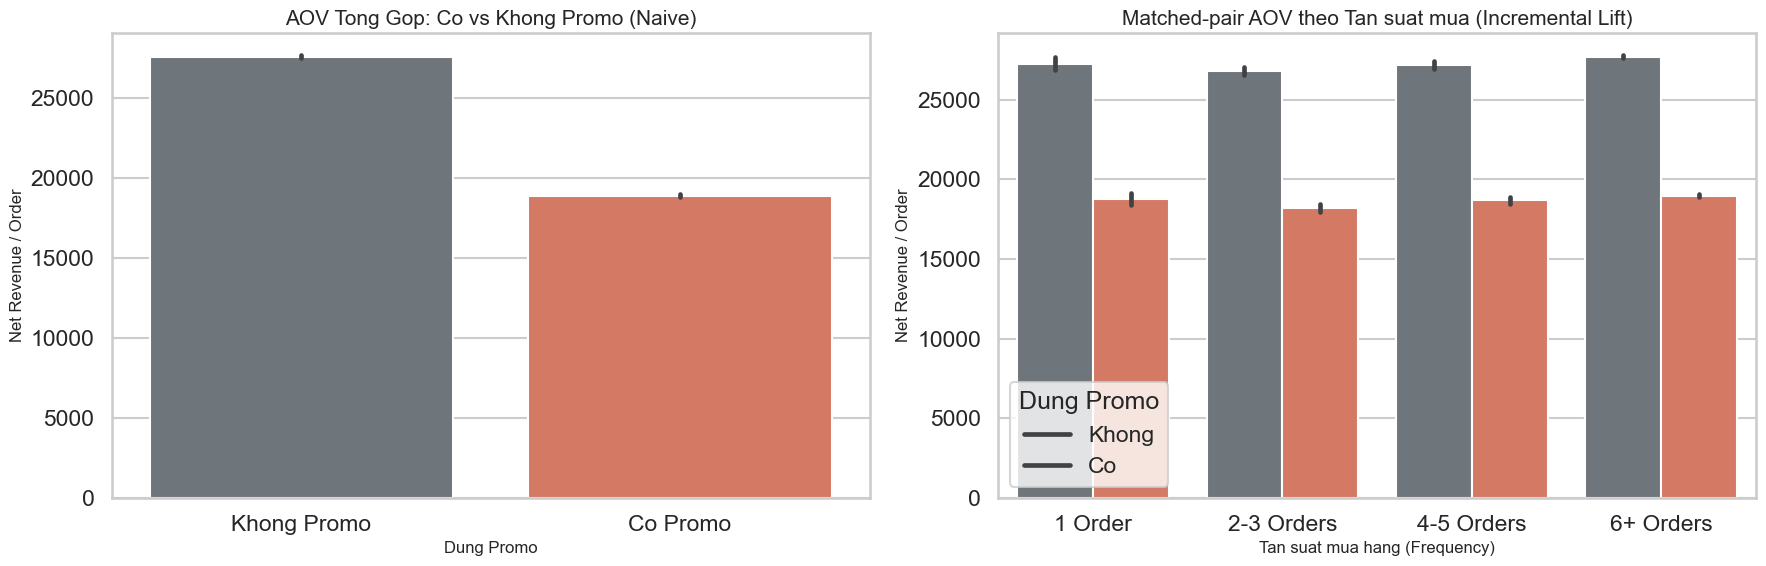

,No_Promo_AOV,Promo_AOV,Incremental_Lift
Frequency_Bucket,,,
1 Order,"$27,250.3","$18,758.1",-31.2%
2-3 Orders,"$26,804.6","$18,219.1",-32.0%
4-5 Orders,"$27,168.9","$18,680.7",-31.2%
6+ Orders,"$27,688.8","$18,984.9",-31.4%


In [6]:
# Phan loai Frequency Buckets cho Matched-pair
def get_freq_bucket(f):
    if pd.isna(f): return "Unknown"
    if f == 1: return "1 Order"
    elif 2 <= f <= 3: return "2-3 Orders"
    elif 4 <= f <= 5: return "4-5 Orders"
    else: return "6+ Orders"

orders_matched = orders_enriched.merge(
    customers_rfm[["customer_id", "Frequency"]], on="customer_id", how="inner"
)
orders_matched["Frequency_Bucket"] = orders_matched["Frequency"].apply(get_freq_bucket)

freq_order = ["1 Order", "2-3 Orders", "4-5 Orders", "6+ Orders"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bieu do AOV Naive (co CI) - fix hue warning
orders_enriched["promo_label"] = orders_enriched["promo_used"].map({True: "Co Promo", False: "Khong Promo"})
sns.barplot(
    data=orders_enriched,
    x="promo_label",
    y="net_revenue",
    hue="promo_label",
    palette={"Khong Promo": "#6c757d", "Co Promo": "#e76f51"},
    legend=False,
    ax=axes[0],
    errorbar=("ci", 95),
    order=["Khong Promo", "Co Promo"]
)
axes[0].set_title("AOV Tong Gop: Co vs Khong Promo (Naive)", fontsize=15)
axes[0].set_xlabel("Dung Promo")
axes[0].set_ylabel("Net Revenue / Order")

# Bieu do Matched Pair (co CI) - hue is already set
sns.barplot(
    data=orders_matched,
    x="Frequency_Bucket",
    y="net_revenue",
    hue="promo_used",
    palette={True: "#e76f51", False: "#6c757d"},
    order=freq_order,
    ax=axes[1],
    errorbar=("ci", 95)
)
axes[1].set_title("Matched-pair AOV theo Tan suat mua (Incremental Lift)", fontsize=15)
axes[1].set_xlabel("Tan suat mua hang (Frequency)")
axes[1].set_ylabel("Net Revenue / Order")
axes[1].legend(title="Dung Promo", labels=["Khong", "Co"])

plt.tight_layout()
plt.show()

# Tinh Incremental Lift %
matched_summary = orders_matched.groupby(
    ["Frequency_Bucket", "promo_used"], as_index=False
)["net_revenue"].mean()
pivot_matched = matched_summary.pivot(
    index="Frequency_Bucket", columns="promo_used", values="net_revenue"
).reindex(freq_order)
pivot_matched.columns = ["No_Promo_AOV", "Promo_AOV"]
pivot_matched["Incremental_Lift"] = (
    (pivot_matched["Promo_AOV"] - pivot_matched["No_Promo_AOV"])
    / pivot_matched["No_Promo_AOV"]
)

display(pivot_matched.style.format({
    "No_Promo_AOV": "${:,.1f}",
    "Promo_AOV": "${:,.1f}",
    "Incremental_Lift": "{:,.1%}"
}).background_gradient(cmap="Greens", subset=["Incremental_Lift"]))

### Hieu suat chuyen doi web traffic

Thay vi chi nhin so don hang, chung ta do ty le `Orders / 1,000 sessions` de danh gia chuyen doi thuc te. 

**Luu y ve bieu do:** De cac nguon traffic de phan biet hon, chung ta dung **FacetGrid** (tach rieng tung nguon) thay vi chong cac duong len nhau.

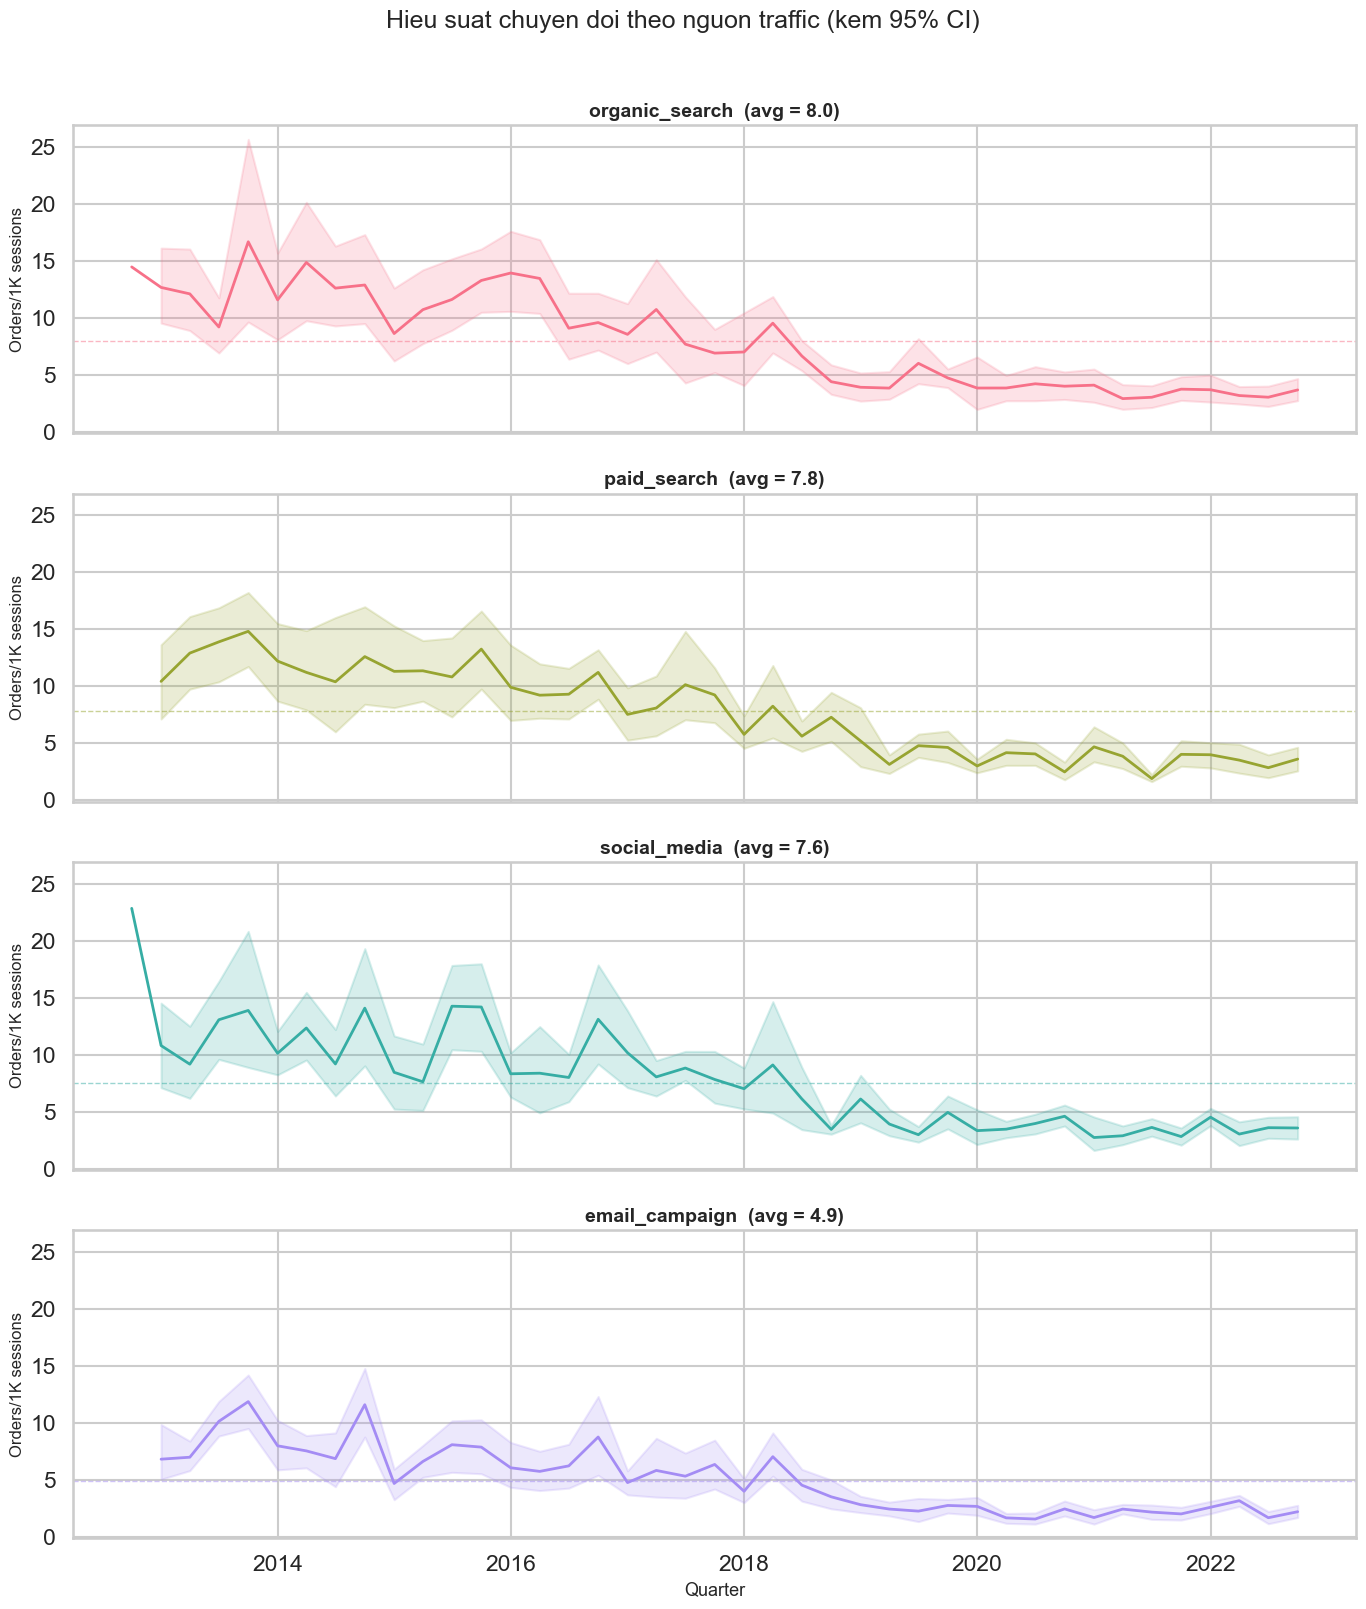

In [7]:
# Su dung data weekly de tinh CI trong moi thang
orders_weekly = (
    orders.assign(week=orders["order_date"].dt.to_period("W").dt.to_timestamp())
    .groupby(["week", "order_source"], as_index=False)
    .size()
    .rename(columns={"size": "orders"})
)
web_weekly = (
    web_traffic.assign(week=web_traffic["date"].dt.to_period("W").dt.to_timestamp())
    .groupby(["week", "traffic_source"], as_index=False)["sessions"]
    .sum()
)
source_eff_weekly = orders_weekly.merge(
    web_weekly, left_on=["week", "order_source"], right_on=["week", "traffic_source"]
)
source_eff_weekly["orders_per_1000_sessions"] = (
    source_eff_weekly["orders"] / source_eff_weekly["sessions"] * 1000
)
source_eff_weekly["quarter"] = source_eff_weekly["week"].dt.to_period("Q").dt.to_timestamp()

top_sources = (
    source_eff_weekly.groupby("order_source")["orders_per_1000_sessions"]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

plot_df = source_eff_weekly[source_eff_weekly["order_source"].isin(top_sources)].copy()

# --- FACETED SUBPLOTS: tach rieng tung nguon traffic ---
n_sources = len(top_sources)
fig, axes = plt.subplots(n_sources, 1, figsize=(14, 4 * n_sources), sharex=True, sharey=True)

colors = sns.color_palette("husl", n_sources)
for idx, source in enumerate(top_sources):
    ax = axes[idx]
    source_data = plot_df[plot_df["order_source"] == source]
    sns.lineplot(
        data=source_data,
        x="quarter",
        y="orders_per_1000_sessions",
        color=colors[idx],
        linewidth=2,
        ax=ax,
        errorbar=("ci", 95),
        err_style="band"
    )
    avg_val = source_data["orders_per_1000_sessions"].mean()
    ax.axhline(y=avg_val, color=colors[idx], linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"{source}  (avg = {avg_val:.1f})", fontsize=14, fontweight="bold")
    ax.set_ylabel("Orders/1K sessions")
    ax.set_xlabel("")

axes[-1].set_xlabel("Quarter", fontsize=13)
fig.suptitle("Hieu suat chuyen doi theo nguon traffic (kem 95% CI)", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

---
**Nhan dinh tu Chuong 2:** Phan tich matched-pair giup loai bo Selection Bias khi danh gia hieu qua khuyen mai. Bieu do faceted cung giup nhin ro xu huong chuyen doi cua tung kenh traffic ma khong bi chen chuc. Cau hoi cuoi cung: **nguyen nhan Churn that su nam o dau, va chat luong san pham co anh huong khong?**

## Chuong 3. Nguyen nhan Churn & Chat luong san pham (Kiem dinh Chi-Square & Simpson's Paradox)

**Muc dich:** Vi Churn Risk duoc tinh tu hanh vi ngung mua (Recency > 365 ngay), chung ta se thuc hien kiem dinh thong ke de xac dinh xem lieu viec khach hang hoan tra hang (Returns) co lam tang ty le Churn hay khong. Ngoai ra, chung ta se phan tich ty le hoan tra tren so don mua theo danh muc de tranh mac phai **Simpson's Paradox** khi danh gia chat luong san pham.

Day la chuong quan trong nham bao dam **tinh nghiem ngat ve mat phuong phap luan** truoc khi dua ra cac de xuat hanh dong va quyet dinh dau tu.

=== Contingency Table (has_return vs Churn_Risk) ===
Churn_Risk   False   True 
has_return                
False       321443  289440
True         18876   17186
Chi-Square Statistic: 1.0310
p-value: 0.3099

=== Category Return Metrics ===


,Ordered_Qty,Returned_Qty,Revenue,Refund_Amount,Return_Rate,Refund_to_Rev_Ratio
category,,,,,,
Streetwear,"1,768,826","59,801","$12,558,477,099","$406,708,249",3.38%,3.24%
Outdoor,"1,170,000","40,417","$2,353,396,797","$78,717,515",3.45%,3.34%
Casual,"107,469","3,499","$440,285,194","$14,027,094",3.26%,3.19%
GenZ,"166,848","5,869","$328,710,176","$11,145,648",3.52%,3.39%


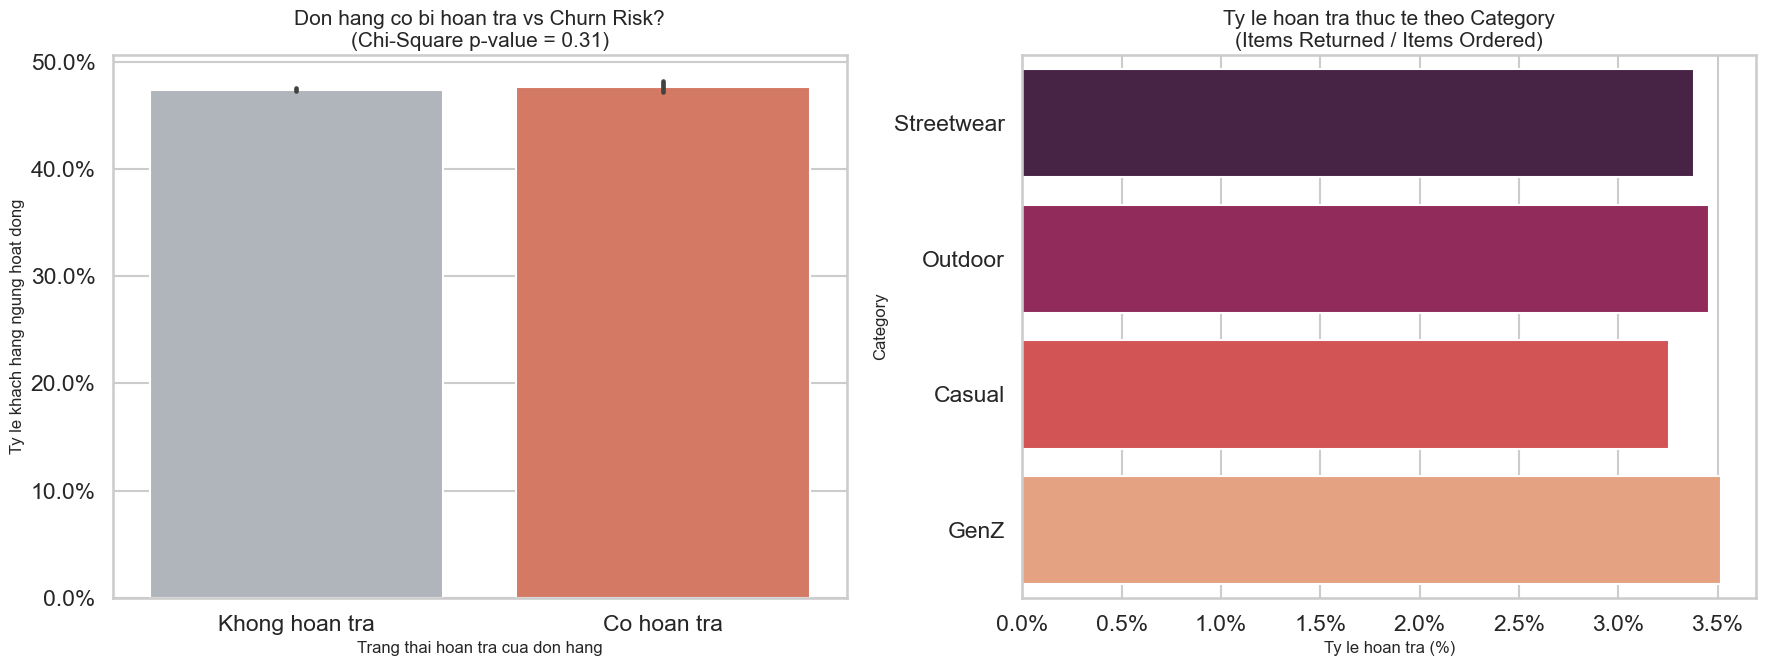

In [8]:
# Loc orders co tra hang
returns_summary = returns.groupby("order_id", as_index=False).agg(
    return_qty=("return_quantity", "sum"),
    refund_sum_val=("refund_amount", "sum")
)

# Gan thong tin tra hang vao enriched orders
orders_returns = orders_enriched.merge(returns_summary, on="order_id", how="left")
orders_returns["has_return"] = orders_returns["order_id"].isin(returns["order_id"])

# Gan them Churn risk cua khach hang
orders_returns = orders_returns.merge(
    customers_rfm[["customer_id", "Churn_Risk"]], on="customer_id", how="left"
)

# --- 1. KIEM DINH CHI-SQUARE CHO MOI QUAN HE RETURNS - CHURN RISK ---
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(orders_returns["has_return"], orders_returns["Churn_Risk"])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print("=== Contingency Table (has_return vs Churn_Risk) ===")
print(contingency_table)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4f}")

# --- 2. TINH TOAN TY LE HOAN TRA THEO CATEGORY (ITEMS & REVENUE) ---
# Tinh tong so luong san pham da dat mua va tong doanh thu thuc te theo tung category
order_items_enriched = order_items.merge(products[["product_id", "category"]], on="product_id", how="left")
total_ordered_qty = order_items_enriched.groupby("category")["quantity"].sum()
total_rev = order_items_enriched.groupby("category")["net_revenue"].sum()

# Tinh tong so luong san pham hoan tra va tong so tien refund theo tung category
returns_enriched = returns.merge(products[["product_id", "category"]], on="product_id", how="left")
total_returned_qty = returns_enriched.groupby("category")["return_quantity"].sum()
total_refund = returns_enriched.groupby("category")["refund_amount"].sum()

# Gop lai va tinh toan ty le
category_metrics = pd.DataFrame({
    "Ordered_Qty": total_ordered_qty,
    "Returned_Qty": total_returned_qty,
    "Revenue": total_rev,
    "Refund_Amount": total_refund
})
category_metrics["Return_Rate"] = category_metrics["Returned_Qty"] / category_metrics["Ordered_Qty"]
category_metrics["Refund_to_Rev_Ratio"] = category_metrics["Refund_Amount"] / category_metrics["Revenue"]
category_metrics = category_metrics.sort_values("Refund_Amount", ascending=False)

print("\n=== Category Return Metrics ===")
display(category_metrics.style.format({
    "Ordered_Qty": "{:,.0f}",
    "Returned_Qty": "{:,.0f}",
    "Revenue": "${:,.0f}",
    "Refund_Amount": "${:,.0f}",
    "Return_Rate": "{:.2%}",
    "Refund_to_Rev_Ratio": "{:.2%}"
}))

# --- 3. VE BIEU DO ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Tac dong cua hoan tra len Churn Risk (voi 95% CI)
orders_returns["return_label"] = orders_returns["has_return"].map(
    {True: "Co hoan tra", False: "Khong hoan tra"}
)
sns.barplot(
    data=orders_returns,
    x="return_label",
    y="Churn_Risk",
    hue="return_label",
    palette={"Khong hoan tra": "#adb5bd", "Co hoan tra": "#e76f51"},
    legend=False,
    ax=axes[0],
    errorbar=("ci", 95),
    order=["Khong hoan tra", "Co hoan tra"]
)
axes[0].set_title(f"Don hang co bi hoan tra vs Churn Risk?\n(Chi-Square p-value = {p_val:.2f})", fontsize=15)
axes[0].set_xlabel("Trang thai hoan tra cua don hang")
axes[0].set_ylabel("Ty le khach hang ngung hoat dong")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

# Plot 2: Ty le hoan tra thuc te theo Category (loai bo Simpson's Paradox)
category_metrics_reset = category_metrics.reset_index()
sns.barplot(
    data=category_metrics_reset,
    x="Return_Rate",
    y="category",
    hue="category",
    palette="rocket",
    legend=False,
    ax=axes[1]
)
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
axes[1].set_title("Ty le hoan tra thuc te theo Category\n(Items Returned / Items Ordered)", fontsize=15)
axes[1].set_xlabel("Ty le hoan tra (%)")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()

### Nhan xet va Bien ho Thong ke Chuong 3:

1. **Bao cao kiem dinh Returns vs. Churn Risk:**
   - Đơn hàng có hoàn trả có tỷ lệ thuộc nhóm khách ngưng hoạt động là **47.7%**, so với **47.4%** ở nhóm không hoàn trả. Sự khác biệt chỉ là **0.3%**.
   - Kiểm định Chi-Square cho giá trị **p-value = 0.31**, lớn hơn nhiều so với ngưỡng ý nghĩa 0.05. Do đó, **khong co su khac biet co y nghia thong ke** về tỷ lệ ngưng hoạt động lâu dài giữa các đơn hàng có và không có hoàn trả. Sự cố hoàn trả đơn lẻ chưa trực tiếp thúc đẩy khách hàng rời bỏ dịch vụ.
   
2. **Simpson's Paradox & Thien lech Quy mo trong hoan tra:**
   - Nếu chỉ nhìn vào tổng số tiền hoàn trả, **Streetwear** đóng góp khoản thiệt hại khổng lồ **$406.7M** (chiếm ~80% toàn hệ thống).
   - Tuy nhiên, khi đối chiếu tỷ lệ hoàn trả thực tế (`Returned_Qty / Ordered_Qty`), **Streetwear chỉ có tỷ lệ hoàn trả là 3.38%**, thấp hơn danh mục **GenZ (3.52%)** và **Outdoor (3.45%)**.
   - Streetwear dẫn đầu về số tiền hoàn trả thuần túy do quy mô doanh thu khổng lồ của nó ($12.56B, chiếm hơn 80% toàn store). Đây là minh chứng rõ rệt cho **Simpson's Paradox (hoặc Quy mô thiên lệch)**. Streetwear không có dấu hiệu chất lượng sản phẩm kém hơn các dòng khác, nhưng do quy mô lớn, chỉ cần giảm nhẹ tỷ lệ hoàn trả tại đây sẽ đem lại hiệu quả tiết kiệm chi phí ròng rất lớn cho doanh nghiệp.

---
## Ket luan hanh dong

### 1. Giu chan tap Champion/Loyal (RFM-driven Retention)

| Insight | Hanh dong |
|:--------|:---------|
| Tap Champion/Loyal dong gop phan lon doanh thu | Xay dung chuong trinh loyalty rieng, early access san pham moi |
| Nhom "At Risk/Churned" co Recency > 365 ngay | Chay chien dich win-back co nhan hoa (email/SMS) truoc moc 365 ngay |
| RFM scoring cho phep phan loai dong (dynamic) | Tich hop RFM scoring vao CRM de auto-trigger cac campaign theo segment |

### 2. Khuyen mai can danh gia tren Incremental Lift (khong phai AOV gop)

| Insight | Hanh dong |
|:--------|:---------|
| So sanh AOV naive bi nhieu boi Selection Bias | Luon dung matched-pair hoac A/B test de do luong hieu qua promo |
| Incremental Lift thuc te co the thap hon ky vong | Thu hep doi tuong nhan promo: uu tien nhom "Standard" can kich cau, khong phat code cho nhom da mua nhieu |
| Cac kenh traffic co hieu suat chuyen doi khac nhau | Phan bo ngan sach theo `orders/1,000 sessions` thay vi chi nhin traffic volume |

### 3. Phong ngua ton that van hanh bang cach giam rui ro hoan tra

| Insight | Hanh dong |
|:--------|:---------|
| Khac biet ve Churn o cap don hang co hoan tra khong co y nghia thong ke (p-value = 0.31) | Su co hoan tra don le chua lam khach roi bo immediately, nhung ma sat nay van can duoc han che de bao ve net revenue. |
| Streetwear gay ro ri lon nhat ($406.7M refund) nhung do thien lech quy mo (Return rate thuc te chỉ 3.38%, thap hon GenZ va Outdoor) | Tap trung cai tien nhe size chart va mo ta san pham cua Streetwear (giam nhe 0.2% return rate giup tiet kiem rong hon $25M). Kiem tra chat luong san pham dong GenZ/Outdoor vi co return rate cao nhat. |
| Giam return rate = tiet kiem truc tiep chi phi van hanh | Dau tu vao pre-purchase guidance (size chart chuan, video review thuc te, danh gia cua khach hang truoc). |

---

> **Luu y ve phuong phap:**
> - **Historical ARPU** la proxy, khong phai true LTV. De tinh LTV chinh xac, can mo hinh du phong nhu BG/NBD + Gamma-Gamma.
> - **Churn Risk** dua tren nguong 365 ngay co dinh. Trong thuc te, nguong nay nen duoc tinh toan tu phan phoi Recency cua tung nganh hang cu the.
> - **Matched-pair analysis** la buoc dau cua causal inference. De co ket qua chac chan hon, can thiet ke A/B test hoac su dung propensity score matching.

Notebook nay phu hop de dung nhu mot ban ke chuyen du lieu o vong trinh bay: moi bieu do tra loi mot cau hoi quan tri, moi chuong dan den chuong tiep theo theo logic tu nhien.